# Classification of Blood Cells using Gaussian Naive Bayes Classifier

Importing required libraries

In [ ]:
import os
!pip install opencv-python
import cv2
import kagglehub
import numpy as np
import seaborn as sns
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from skimage.feature import local_binary_pattern
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


Importing Dataset


In [ ]:
paultimothymooney_blood_cells_path = kagglehub.dataset_download('paultimothymooney/blood-cells')
print('Data source import complete at:', paultimothymooney_blood_cells_path)

train_dir = os.path.join(paultimothymooney_blood_cells_path, "dataset2-master/dataset2-master/images/TRAIN")
test_dir = os.path.join(paultimothymooney_blood_cells_path, "dataset2-master/dataset2-master/images/TEST")

print(f"Train dir: {train_dir}")
print(f"Test dir: {test_dir}")

Using Colab cache for faster access to the 'blood-cells' dataset.
Data source import complete at: /kaggle/input/blood-cells
Train dir: /kaggle/input/blood-cells/dataset2-master/dataset2-master/images/TRAIN
Test dir: /kaggle/input/blood-cells/dataset2-master/dataset2-master/images/TEST


In [ ]:
def load_images(directory):
    """Load all images from directory using PIL"""
    images = []
    labels = []
    class_names = sorted(os.listdir(directory))

    for class_idx, class_name in enumerate(class_names):
        class_path = os.path.join(directory, class_name)

        if not os.path.isdir(class_path):
            continue

        image_files = os.listdir(class_path)
        print(f"  {class_name}: {len(image_files)} images")

        for img_file in image_files:
            img_path = os.path.join(class_path, img_file)
            img = Image.open(img_path).convert('RGB')
            img_array = np.array(img)
            images.append(img_array)
            labels.append(class_idx)

    return images, np.array(labels), class_names

In [ ]:
train_imgs, train_labels, class_names = load_images(train_dir)
test_imgs, test_labels, _ = load_images(test_dir)

print(f"\nTotal train: {len(train_imgs)}, Total test: {len(test_imgs)}")
print(f"Classes: {class_names}")

  EOSINOPHIL: 2497 images
  LYMPHOCYTE: 2483 images
  MONOCYTE: 2478 images
  NEUTROPHIL: 2499 images
  EOSINOPHIL: 623 images
  LYMPHOCYTE: 620 images
  MONOCYTE: 620 images
  NEUTROPHIL: 624 images

Total train: 9957, Total test: 2487
Classes: ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']


## Helper Functions

In [ ]:
def segment_wbc(image):
    """Isolate the white blood cell from background RBCs"""
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    lower = np.array([100, 40, 40])
    upper = np.array([160, 255, 255])
    mask = cv2.inRange(hsv, lower, upper)

    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)

    return mask

In [ ]:
class BloodCellClassifier:
    def __init__(self):
        self.model = GaussianNB()

    def fit(self, X, y):
        print(f"Training with {X.shape[0]} samples, {X.shape[1]} features")
        self.model.fit(X, y)
        print("Completed training.")

    def predict(self, X):
        return self.model.predict(X)

    def evaluate(self, X, y_true):
        y_pred = self.predict(X)
        accuracy = accuracy_score(y_true, y_pred)
        return accuracy, y_pred

In [ ]:
def plot_heatmap(title, y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

In [ ]:
def run_and_evaluate_feature(feature: str, train_imgs, test_imgs, feature_extraction_method):
    X_train = feature_extraction_method(train_imgs)
    X_test = feature_extraction_method(test_imgs)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    classifier = BloodCellClassifier()
    classifier.fit(X_train_scaled, train_labels)
    train_acc, _ = classifier.evaluate(X_train_scaled, train_labels)
    test_acc, pred = classifier.evaluate(X_test_scaled, test_labels)

    print(f"{feature} - Train: {train_acc*100:.2f}%, Test: {test_acc*100:.2f}%")
    plot_heatmap(f"{feature}", test_labels, pred, class_names)

Show samples and show masks

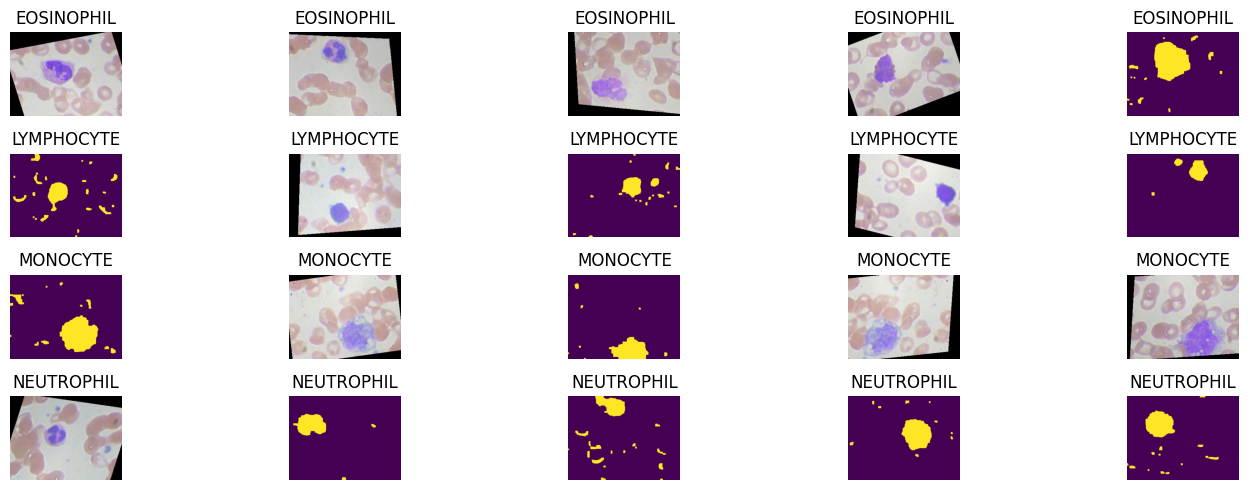

In [ ]:
# display some of the images of each classes, 3 original, 2 masks
import random
def display_sample_images(images, labels, class_names, num_samples=5):
    """Display sample images for each class."""
    plt.figure(figsize=(15, 5))
    for i, class_name in enumerate(class_names):
        class_indices = [j for j, label in enumerate(labels) if label == i]
        sample_indices = random.sample(class_indices, min(num_samples, len(class_indices)))

        for k, img_index in enumerate(sample_indices):
            plt.subplot(len(class_names), num_samples, i * num_samples + k + 1)
            image = images[img_index]
            mask = segment_wbc(image)
            if img_index % 2 == 0:
                plt.imshow(image)
            else:
                plt.imshow(mask)
            plt.title(class_name)
            plt.axis('off')
    plt.tight_layout()
    plt.show()

display_sample_images(train_imgs, train_labels, class_names)

Mean RGB Features


Training with 9957 samples, 3 features
Completed training.
Mean RGB Features - Train: 30.37%, Test: 25.69%


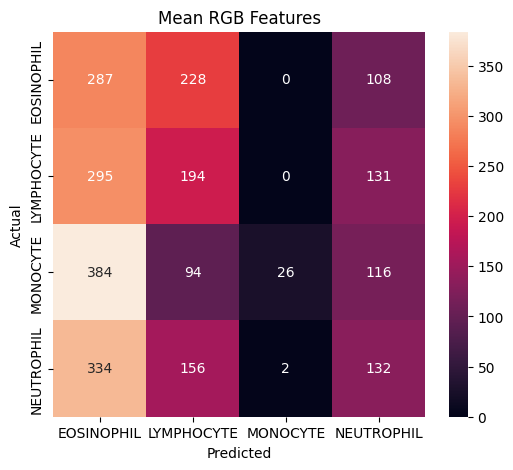

In [ ]:
def extract_mean_rgb(images):
    """Calculate mean of RGB channels"""
    features = []
    for image in images:
        mean_r = np.mean(image[:, :, 0])
        mean_g = np.mean(image[:, :, 1])
        mean_b = np.mean(image[:, :, 2])
        features.append([mean_r, mean_g, mean_b])
    return np.array(features)

run_and_evaluate_feature("Mean RGB Features", train_imgs, test_imgs, extract_mean_rgb)

RGB Histogram

Training with 9957 samples, 36 features
Completed training.
RGB Histogram (Unmasked, 48 bins) - Train: 46.95%, Test: 41.25%


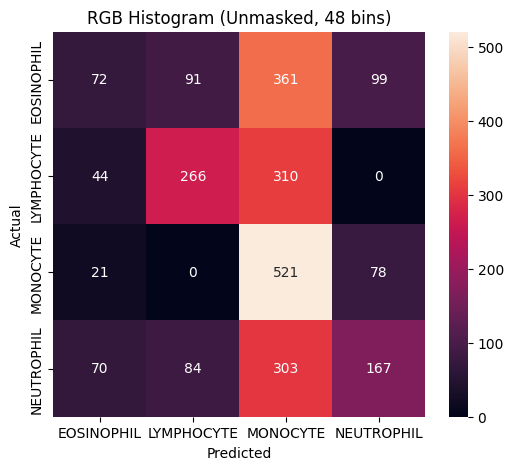

In [ ]:
def extract_rgb_histogram(images, bins=12):
    """RGB histogram"""
    features = []
    for image in images:
        hist_r = np.histogram(image[:, :, 0], bins=bins, range=(0, 256))[0]
        hist_g = np.histogram(image[:, :, 1], bins=bins, range=(0, 256))[0]
        hist_b = np.histogram(image[:, :, 2], bins=bins, range=(0, 256))[0]
        feature = np.concatenate([hist_r, hist_g, hist_b])
        features.append(feature)
    return np.array(features)

run_and_evaluate_feature("RGB Histogram 12 bins ", train_imgs, test_imgs, extract_rgb_histogram)

Training with 9957 samples, 144 features
Completed training.
RGB Histogram (Unmasked, 48 bins) - Train: 50.17%, Test: 42.74%


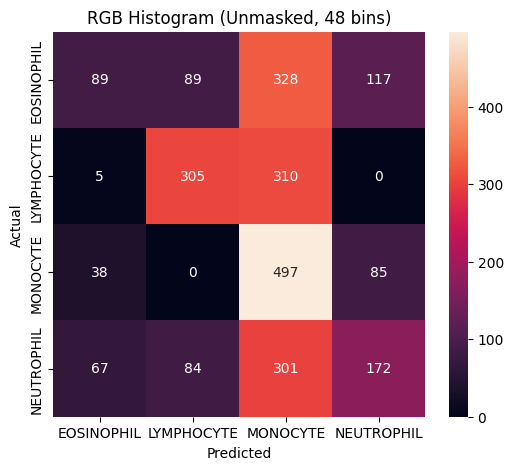

In [ ]:
def extract_rgb_histogram(images, bins=48):
    """RGB histogram"""
    features = []
    for image in images:
        hist_r = np.histogram(image[:, :, 0], bins=bins, range=(0, 256))[0]
        hist_g = np.histogram(image[:, :, 1], bins=bins, range=(0, 256))[0]
        hist_b = np.histogram(image[:, :, 2], bins=bins, range=(0, 256))[0]
        feature = np.concatenate([hist_r, hist_g, hist_b])
        features.append(feature)
    return np.array(features)

run_and_evaluate_feature("RGB Histogram 48 bins", train_imgs, test_imgs, extract_rgb_histogram)

Training with 9957 samples, 192 features
Completed training.
RGB Histogram 48 bins - Train: 49.64%, Test: 40.85%


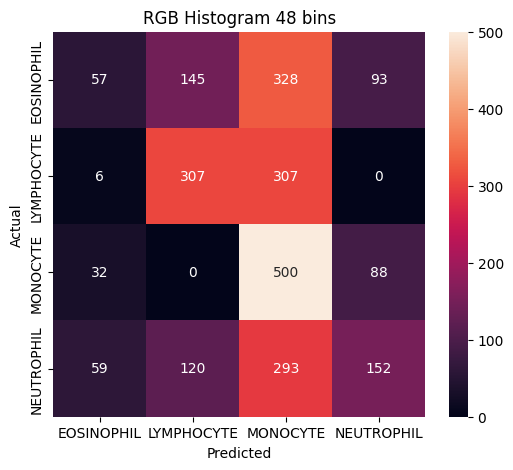

In [ ]:
def extract_rgb_histogram(images, bins=64):
    """RGB histogram"""
    features = []
    for image in images:
        hist_r = np.histogram(image[:, :, 0], bins=bins, range=(0, 256))[0]
        hist_g = np.histogram(image[:, :, 1], bins=bins, range=(0, 256))[0]
        hist_b = np.histogram(image[:, :, 2], bins=bins, range=(0, 256))[0]
        feature = np.concatenate([hist_r, hist_g, hist_b])
        features.append(feature)
    return np.array(features)

run_and_evaluate_feature("RGB Histogram 64 bins", train_imgs, test_imgs, extract_rgb_histogram)

HSV Histogram


Training with 9957 samples, 48 features
Completed training.
HSV Histogram (Unmasked, 64 bins) - Train: 63.05%, Test: 51.35%


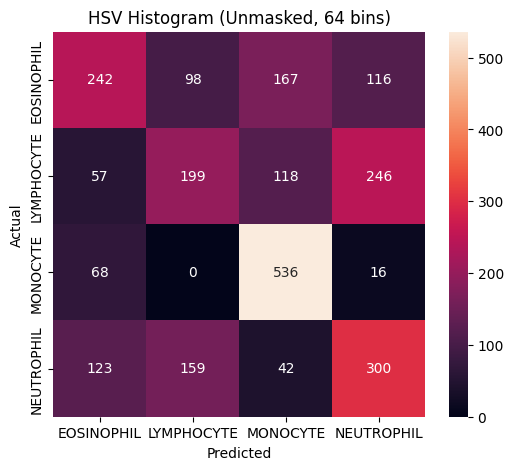

In [ ]:
def extract_hsv_histogram(images, bins=16):
    """HSV color distribution"""
    features = []
    for image in images:
        hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
        hist_h = np.histogram(hsv[:, :, 0], bins=bins, range=(0, 180))[0]
        hist_s = np.histogram(hsv[:, :, 1], bins=bins, range=(0, 256))[0]
        hist_v = np.histogram(hsv[:, :, 2], bins=bins, range=(0, 256))[0]
        feature = np.concatenate([hist_h, hist_s, hist_v])
        features.append(feature)
    return np.array(features)

run_and_evaluate_feature("HSV Histogram 16 bins", train_imgs, test_imgs, extract_hsv_histogram)

Training with 9957 samples, 96 features
Completed training.
HSV Histogram (Unmasked, 64 bins) - Train: 68.04%, Test: 53.24%


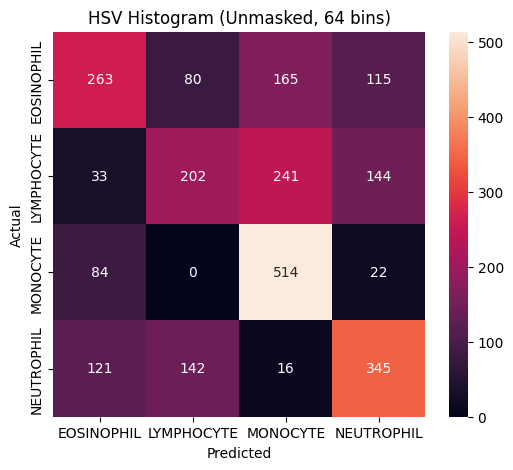

In [ ]:
def extract_hsv_histogram(images, bins=32):
    """HSV color distribution"""
    features = []
    for image in images:
        hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
        hist_h = np.histogram(hsv[:, :, 0], bins=bins, range=(0, 180))[0]
        hist_s = np.histogram(hsv[:, :, 1], bins=bins, range=(0, 256))[0]
        hist_v = np.histogram(hsv[:, :, 2], bins=bins, range=(0, 256))[0]
        feature = np.concatenate([hist_h, hist_s, hist_v])
        features.append(feature)
    return np.array(features)

run_and_evaluate_feature("HSV Histogram 32 bins", train_imgs, test_imgs, extract_hsv_histogram)

Training with 9957 samples, 192 features
Completed training.
HSV Histogram (Unmasked, 64 bins) - Train: 68.64%, Test: 55.73%


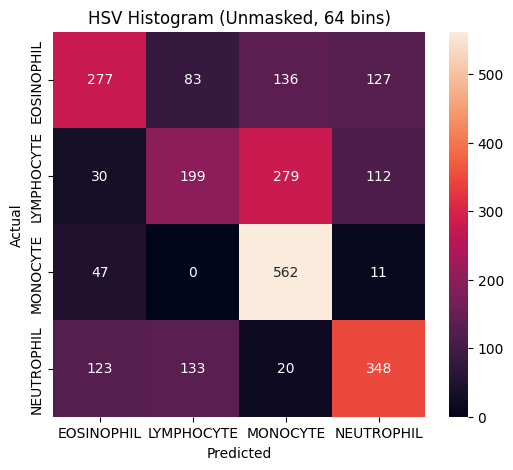

In [ ]:
def extract_hsv_histogram(images, bins=64):
    """HSV color distribution"""
    features = []
    for image in images:
        hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
        hist_h = np.histogram(hsv[:, :, 0], bins=bins, range=(0, 180))[0]
        hist_s = np.histogram(hsv[:, :, 1], bins=bins, range=(0, 256))[0]
        hist_v = np.histogram(hsv[:, :, 2], bins=bins, range=(0, 256))[0]
        feature = np.concatenate([hist_h, hist_s, hist_v])
        features.append(feature)
    return np.array(features)

run_and_evaluate_feature("HSV Histogram 64 bins", train_imgs, test_imgs, extract_hsv_histogram)

Texture Features: Local Binary Pattern

100%|██████████| 2487/2487 [00:49<00:00, 50.63it/s]


Training with 9957 samples, 10 features
Completed training.
Texture LBP (Unmasked) - Train: 35.49%, Test: 31.44%


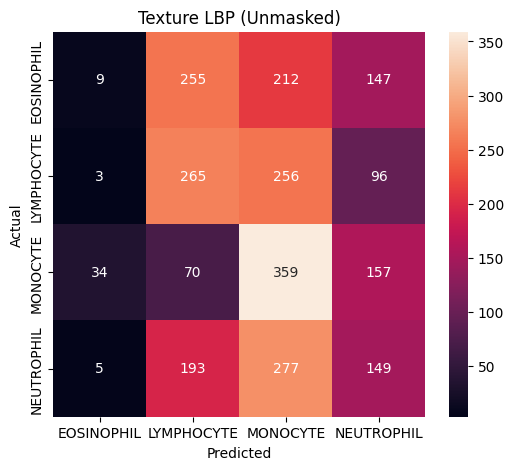

In [ ]:
def extract_texture_lbp(images, bins=10):
    features = []
    for image in tqdm(images):
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        lbp = local_binary_pattern(gray, P=8, R=1, method='uniform')
        hist, _ = np.histogram(lbp.ravel(), bins=bins, range=(0, 10))
        features.append(hist)
    return np.array(features)

run_and_evaluate_feature("Texture LBP 10 bins: ", train_imgs, test_imgs, extract_texture_lbp)

100%|██████████| 2487/2487 [00:50<00:00, 49.66it/s]


Training with 9957 samples, 32 features
Completed training.
Texture LBP (Unmasked) - Train: 35.49%, Test: 31.44%


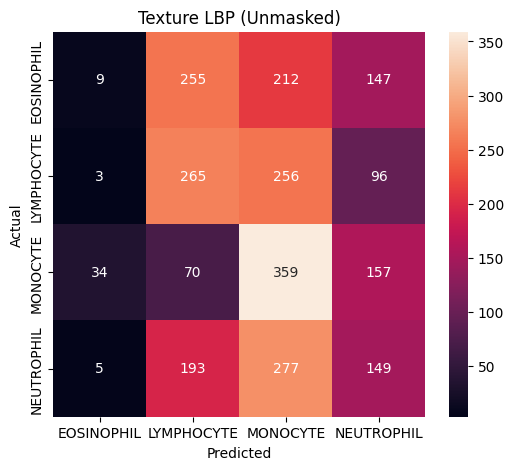

In [ ]:
def extract_texture_lbp(images, bins=32):
    features = []
    for image in tqdm(images):
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        lbp = local_binary_pattern(gray, P=8, R=1, method='uniform')
        hist, _ = np.histogram(lbp.ravel(), bins=bins, range=(0, 10))
        features.append(hist)
    return np.array(features)

run_and_evaluate_feature("Texture LBP 32 bins: ", train_imgs, test_imgs, extract_texture_lbp)

## Now using mask i.e. WBC Segmentation

HSV Histogram

100%|██████████| 2487/2487 [00:04<00:00, 574.54it/s]


Training with 9957 samples, 192 features
Completed training.
HSV Histogram (Masked, 64 bins) - Train: 71.03%, Test: 60.27%


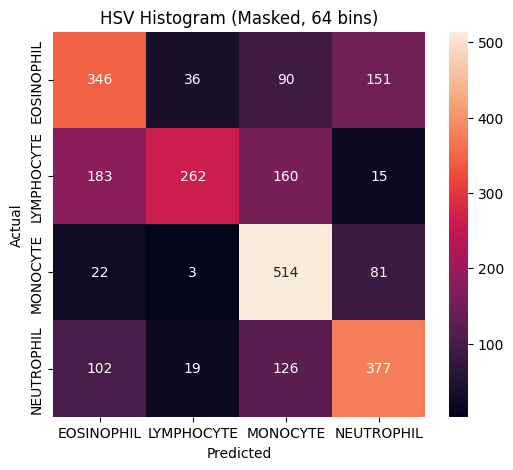

In [ ]:
def extract_hsv_histogram_masked(images, bins=64):
    """HSV histogram with WBC masking"""
    features = []
    for image in tqdm(images):
        mask = segment_wbc(image)
        hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

        feat = []
        for i, (low, high) in enumerate([(0, 180), (0, 256), (0, 256)]):
            channel = hsv[:, :, i]
            masked_pixels = channel[mask > 0]

            if len(masked_pixels) > 0:
                hist, _ = np.histogram(masked_pixels, bins=bins, range=(low, high))
                hist = hist.astype(float) / (hist.sum() + 1e-6)
            else:
                hist = np.zeros(bins)
            feat.extend(hist)

        features.append(feat)
    return np.array(features)

run_and_evaluate_feature("HSV Histogram Masked, 64 bins", train_imgs, test_imgs, extract_hsv_histogram_masked)

RGB Histogram with WBC Mask

100%|██████████| 2487/2487 [00:03<00:00, 628.06it/s]


Training with 9957 samples, 144 features
Completed training.
RGB Histogram (Masked, 48 bins) - Train: 52.54%, Test: 40.61%


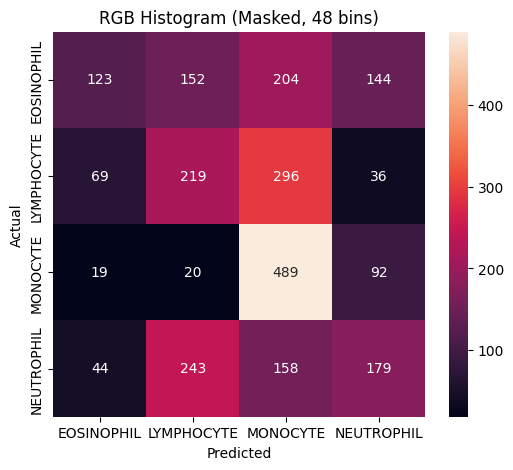

In [ ]:
def extract_rgb_histogram_masked(images, bins=48):
    """RGB histogram on WBC region only, normalized"""
    features = []
    for image in tqdm(images):
        mask = segment_wbc(image)

        feat = []
        for i in range(3):
            channel = image[:, :, i]
            masked_pixels = channel[mask > 0]

            if len(masked_pixels) > 0:
                hist, _ = np.histogram(masked_pixels, bins=bins, range=(0, 256))
                hist = hist.astype(float) / (hist.sum() + 1e-6)
            else:
                hist = np.zeros(bins)
            feat.extend(hist)

        features.append(feat)
    return np.array(features)

run_and_evaluate_feature("RGB Histogram (Masked, 48 bins)", train_imgs, test_imgs, extract_rgb_histogram_masked)

Texture LBP with WBC Mask

100%|██████████| 2487/2487 [00:48<00:00, 51.36it/s]


Training with 9957 samples, 20 features
Completed training.
Texture LBP (Masked) - Train: 50.87%, Test: 49.42%


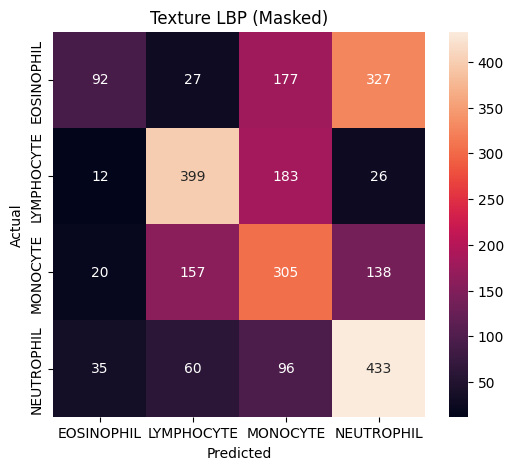

In [ ]:
def extract_texture_lbp_masked(images, bins=10):
    """LBP texture on WBC region only, normalized"""
    features = []
    for image in tqdm(images):
        mask = segment_wbc(image)
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        lbp = local_binary_pattern(gray, P=8, R=1, method='uniform')

        masked_lbp = lbp[mask > 0]
        if len(masked_lbp) > 0:
            hist, _ = np.histogram(masked_lbp, bins=bins, range=(0, 10))
            hist = hist.astype(float) / (hist.sum() + 1e-6)
        else:
            hist = np.zeros(bins)

        features.append(hist)
    return np.array(features)

run_and_evaluate_feature("Texture LBP (Masked)", train_imgs, test_imgs, extract_texture_lbp_masked)

## Higher Order Statistics

100%|██████████| 2487/2487 [00:09<00:00, 253.54it/s]


Training with 9957 samples, 9 features
Completed training.
Color Stats (Masked) - Train: 57.07%, Test: 57.14%


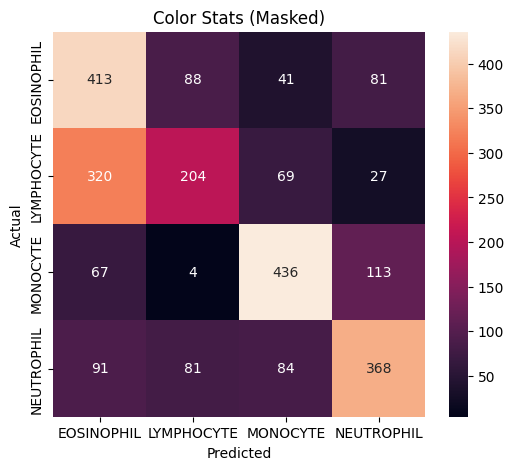

In [ ]:
def extract_color_stats_masked(images):
    """Higher order statistics"""
    features = []
    for image in tqdm(images):
        mask = segment_wbc(image)
        hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

        feat = []
        for i in range(3):
            channel = hsv[:, :, i]
            masked_pixels = channel[mask > 0]

            if len(masked_pixels) > 0:
                feat.append(np.mean(masked_pixels))
                feat.append(np.std(masked_pixels))
                feat.append(skew(masked_pixels))
            else:
                feat.extend([0, 0, 0])

        features.append(feat)
    return np.array(features)

run_and_evaluate_feature("Color Stats (Masked)", train_imgs, test_imgs, extract_color_stats_masked)

## Cell Morphology Features

In [ ]:
def count_nucleus_lobes(image):
    """Count number of nucleus segments/lobes"""
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    lower = np.array([120, 50, 20])
    upper = np.array([160, 255, 180])
    nucleus_mask = cv2.inRange(hsv, lower, upper)

    kernel = np.ones((3, 3), np.uint8)
    nucleus_mask = cv2.morphologyEx(nucleus_mask, cv2.MORPH_OPEN, kernel)

    num_labels, _ = cv2.connectedComponents(nucleus_mask)
    return num_labels - 1


def get_nucleus_shape_features(image):
    """Calculate circularity and solidity of nucleus"""
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    lower = np.array([120, 50, 20])
    upper = np.array([160, 255, 180])
    nucleus_mask = cv2.inRange(hsv, lower, upper)

    contours, _ = cv2.findContours(nucleus_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        return 0, 0

    cnt = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)

    circularity = (4 * np.pi * area) / (perimeter ** 2 + 1e-6)

    hull = cv2.convexHull(cnt)
    hull_area = cv2.contourArea(hull)
    solidity = area / (hull_area + 1e-6)

    return circularity, solidity


def count_granules(image):
    """Count orange/pink granules - key for identifying Eosinophils"""
    wbc_mask = segment_wbc(image)
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

    lower = np.array([0, 50, 100])
    upper = np.array([25, 255, 255])
    granule_mask = cv2.inRange(hsv, lower, upper)

    granule_mask = cv2.bitwise_and(granule_mask, wbc_mask)
    return np.sum(granule_mask > 0)


def get_nc_ratio(image):
    """Calculate nucleus to cytoplasm ratio"""
    wbc_mask = segment_wbc(image)
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

    lower = np.array([120, 50, 20])
    upper = np.array([160, 255, 180])
    nucleus_mask = cv2.inRange(hsv, lower, upper)

    nucleus_area = np.sum(nucleus_mask > 0)
    wbc_area = np.sum(wbc_mask > 0)

    return nucleus_area / (wbc_area + 1e-6)


def get_cell_size(image):
    """Get WBC area as proportion of image"""
    wbc_mask = segment_wbc(image)
    return np.sum(wbc_mask > 0) / wbc_mask.size

100%|██████████| 2487/2487 [00:11<00:00, 216.40it/s]


Training with 9957 samples, 6 features
Completed training.
Cell Morphology Features - Train: 41.51%, Test: 44.95%


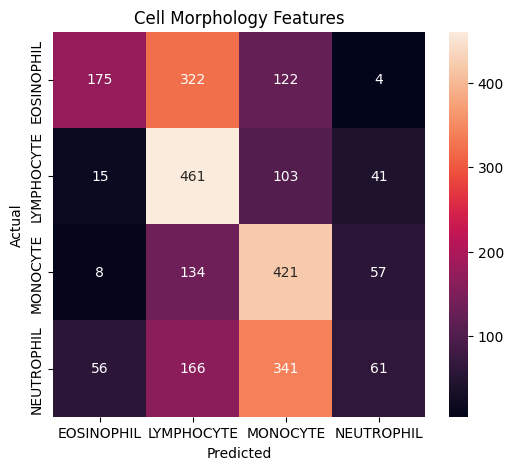

In [ ]:
def extract_cell_morphology(images):
    """Extract all cell morphology features"""
    features = []
    for image in tqdm(images):
        feat = []
        feat.append(count_nucleus_lobes(image))

        circ, solid = get_nucleus_shape_features(image)
        feat.extend([circ, solid])
        feat.append(count_granules(image))
        feat.append(get_nc_ratio(image))
        feat.append(get_cell_size(image))

        features.append(feat)
    return np.array(features)

run_and_evaluate_feature("Cell Morphology Features", train_imgs, test_imgs, extract_cell_morphology)

Masked HSV + Cell Morphology

100%|██████████| 2487/2487 [00:11<00:00, 218.68it/s]


Training with 9957 samples, 198 features
Completed training.
Masked HSV + Cell Morphology - Train: 71.52%, Test: 60.92%


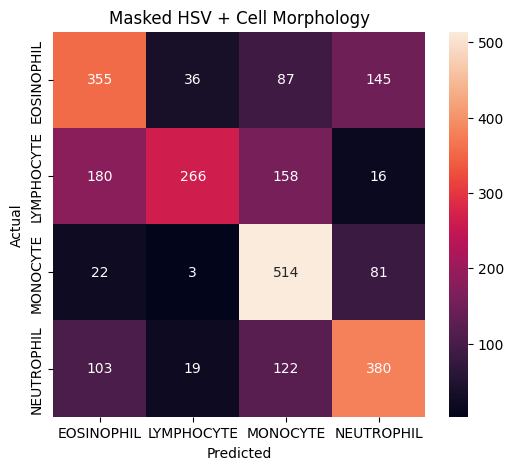

In [ ]:
def extract_combo_hsv_morphology(images):
    """Combine masked HSV histogram with cell morphology"""
    hsv_feat = extract_hsv_histogram_masked(images, bins=64)
    morph_feat = extract_cell_morphology(images)
    return np.hstack([hsv_feat, morph_feat])

run_and_evaluate_feature("Masked HSV + Cell Morphology", train_imgs, test_imgs, extract_combo_hsv_morphology)

Masked HSV + Masked Texture

100%|██████████| 2487/2487 [00:48<00:00, 51.45it/s]


Training with 9957 samples, 202 features
Completed training.
Masked HSV + Masked Texture - Train: 73.39%, Test: 65.10%


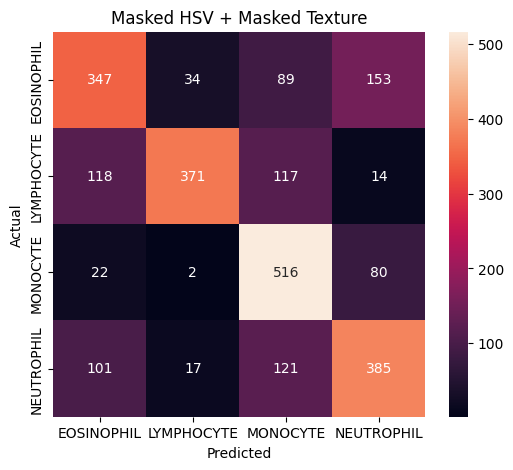

In [ ]:
def extract_combo_hsv_texture(images):
    """Combine masked HSV histogram with masked texture"""
    hsv_feat = extract_hsv_histogram_masked(images, bins=64)
    texture_feat = extract_texture_lbp_masked(images, bins=10)
    return np.hstack([hsv_feat, texture_feat])

run_and_evaluate_feature("Masked HSV + Masked Texture", train_imgs, test_imgs, extract_combo_hsv_texture)

Cell Morphology Features and HSV Masked Histology features got good results


100%|██████████| 2487/2487 [00:11<00:00, 209.77it/s]


Training with 9957 samples, 198 features
Completed training.
Dual Color (Masked) + Cell Morphology - Train: 71.52%, Test: 60.92%


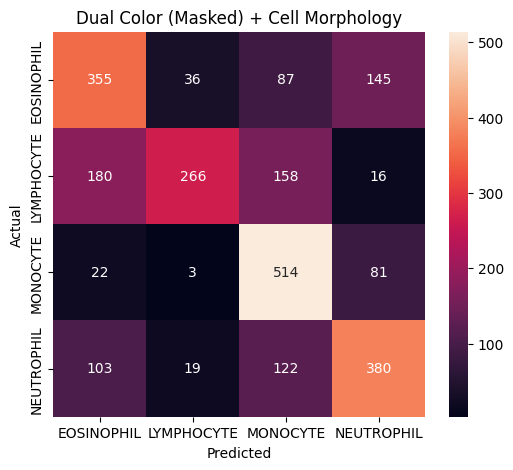

In [ ]:
def extract_combo_dual_color(images):
    hsv_features = extract_hsv_histogram_masked(images, bins=64)
    morph_features = extract_cell_morphology(images)
    return np.hstack([hsv_features, morph_features])

run_and_evaluate_feature("HSV Histology + Cell Morphology", train_imgs, test_imgs, extract_combo_dual_color)

Combining all effective features

100%|██████████| 2487/2487 [00:14<00:00, 173.29it/s]


Training with 9957 samples, 217 features
Completed training.
Color Stats + Masked HSV + RGB + Cell Morphology - Train: 73.37%, Test: 65.26%


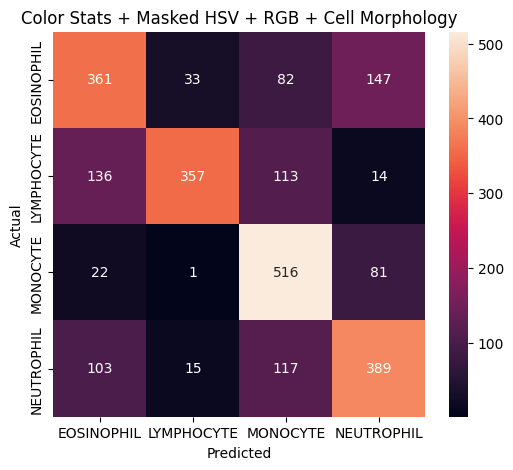

In [ ]:
def extract_combo_stats_hist_morph(images):
    """Color statistics + HSV histogram + morphology"""
    texture_features = extract_texture_lbp_masked(images)
    hsv_features = extract_hsv_histogram_masked(images, bins=64)
    # rgb_features = extract_rgb_histogram_masked(images, bins=24)
    color_features = extract_color_stats_masked(images)
    morph_features = extract_cell_morphology(images)
    return np.hstack([morph_features, texture_features, hsv_features, color_features])

run_and_evaluate_feature("Color Stats + Masked HSV + RGB + Cell Morphology", train_imgs, test_imgs, extract_combo_stats_hist_morph)

## Using previous combination and using k-fold instead of standard split

Combining train and test sets for cross-validation...
Total dataset: 12444 images
Class distribution: {'EOSINOPHIL': np.int64(3120), 'LYMPHOCYTE': np.int64(3103), 'MONOCYTE': np.int64(3098), 'NEUTROPHIL': np.int64(3123)}
K-Fold Evaluation: Feature Combination with n=5


100%|██████████| 12444/12444 [00:56<00:00, 219.42it/s]
Evaluating Feature Combination: 5it [00:00,  7.77it/s]


Train Accuracy: 72.59% (±0.39%)
Validation Accuracy:   72.21% (±0.73%)


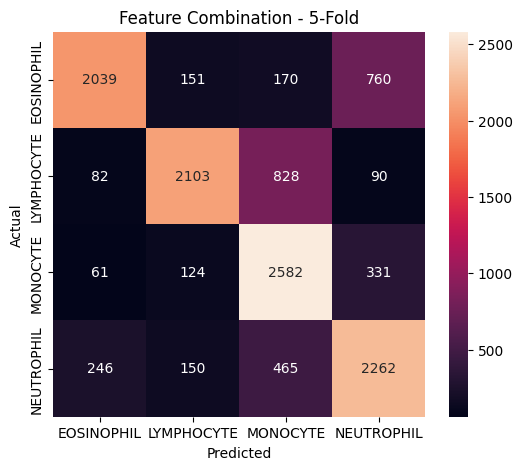

K-Fold Evaluation: Conbined Features with K(=10)-Fold with n=10


100%|██████████| 12444/12444 [00:57<00:00, 217.09it/s]
Evaluating Conbined Features with K(=10)-Fold: 10it [00:01,  7.31it/s]


Train Accuracy: 72.55% (±0.45%)
Validation Accuracy:   72.11% (±0.91%)


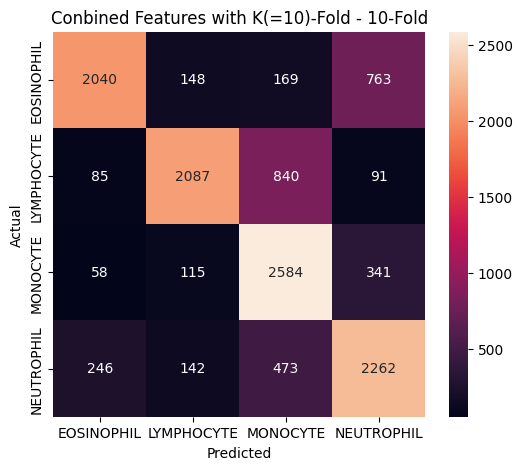

In [ ]:
def run_kfold_evaluation(feature_name, all_images, all_labels, feature_extraction_method, n_folds=5):
    """running GNB with K-fold"""
    print(f"K-Fold Evaluation: {feature_name} with n={n_folds}")

    X = feature_extraction_method(all_images)
    y = all_labels

    kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    fold_train_accs = []
    fold_test_accs = []
    all_y_true = []
    all_y_pred = []

    for fold_idx, (train_idx, val_idx) in tqdm(enumerate(kf.split(X, y), 1), desc=f"Evaluating {feature_name}"):
        # Split data
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        # Scale features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)

        # Train and evaluate
        classifier = GaussianNB()
        classifier.fit(X_train_scaled, y_train)

        train_pred = classifier.predict(X_train_scaled)
        val_pred = classifier.predict(X_val_scaled)

        train_acc = accuracy_score(y_train, train_pred)
        val_acc = accuracy_score(y_val, val_pred)

        fold_train_accs.append(train_acc)
        fold_test_accs.append(val_acc)

        all_y_true.extend(y_val)
        all_y_pred.extend(val_pred)


    train_acc = np.mean(fold_train_accs) * 100
    std_train = np.std(fold_train_accs) * 100
    val_acc = np.mean(fold_test_accs) * 100
    std_val = np.std(fold_test_accs) * 100

    print(f"Train Accuracy: {train_acc:.2f}% (±{std_train:.2f}%)")
    print(f"Validation Accuracy:   {val_acc:.2f}% (±{std_val:.2f}%)")

    # Confusion matrix
    plot_heatmap(f"{feature_name} - {n_folds}-Fold", np.array(all_y_true), np.array(all_y_pred), class_names)


# K Fold Mix
all_images = train_imgs + test_imgs
all_labels = np.concatenate([train_labels, test_labels])


# k = 5
run_kfold_evaluation(
    "Feature Combination", all_images, all_labels, extract_combo_stats_hist_morph, n_folds=5
)

# Also test with 10-fold
run_kfold_evaluation(
    "Combined Features with K(=10)-Fold", all_images, all_labels, extract_combo_stats_hist_morph,n_folds=10
)